In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/fer_dataset"


Mounted at /content/drive


In [ ]:
!pip install -q scikit-learn pandas pillow matplotlib tqdm


In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.ensemble import IsolationForest


In [ ]:
data_dir = Path(DATA_DIR)
assert data_dir.exists(), f"{DATA_DIR} not found! Update DATA_DIR variable."

img_exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
filepaths = []
labels = []
for class_dir in sorted([d for d in data_dir.iterdir() if d.is_dir()]):
    for ext in img_exts:
        for p in class_dir.rglob(ext):
            filepaths.append(str(p))
            labels.append(class_dir.name)

df_files = pd.DataFrame({"filepath": filepaths, "label": labels})
print("Total images found:", len(df_files))
print("Classes found:", df_files['label'].unique())
df_files.head()


Total images found: 36912
Classes found: ['fer_dataset']


,filepath,label
0,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
1,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
2,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
3,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
4,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset


from matplotlib import pyplot as plt
import seaborn as sns
_df_0.groupby('filepath').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
def compute_image_stats(path, resize_for_stats=None):
    """
    Open image with PIL, compute basic statistics.
    resize_for_stats: (w,h) if you want to downsize before computing stats (optional).
    Returns dict or raises exception.
    """
    with Image.open(path) as img:
        img = img.convert("RGB")
        if resize_for_stats:
            img = img.resize(resize_for_stats)
        arr = np.asarray(img).astype(np.float32)
        h, w = arr.shape[:2]
        mean_pixel = arr.mean()
        std_pixel = arr.std()
        gray = np.dot(arr[..., :3], [0.2989, 0.5870, 0.1140])
        brightness = gray.mean()
        aspect_ratio = w / h if h != 0 else np.nan
        return {"width": w, "height": h, "mean": mean_pixel,
                "std": std_pixel, "brightness": brightness,
                "aspect_ratio": aspect_ratio}

rows = []
bad_files = []
for idx, row in tqdm(df_files.iterrows(), total=len(df_files)):
    p = row['filepath']
    try:
        stats = compute_image_stats(p, resize_for_stats=(64,64))
        stats['filepath'] = p
        stats['label'] = row['label']
        rows.append(stats)
    except Exception as e:
        bad_files.append(p)

print("Unreadable/corrupted files:", len(bad_files))
if bad_files:
    print("Example corrupted:", bad_files[:5])

df_stats = pd.DataFrame(rows)
df_stats.head()


100%|██████████| 36912/36912 [6:20:47<00:00,  1.62it/s]

Unreadable/corrupted files: 0


,width,height,mean,std,brightness,aspect_ratio,filepath,label
0,64,64,134.190674,79.316711,134.449308,1.0,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
1,64,64,60.928875,42.086079,64.959917,1.0,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
2,64,64,76.029213,58.142353,78.128685,1.0,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
3,64,64,83.520348,50.687550,84.780327,1.0,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset
4,64,64,72.376625,36.702618,72.438492,1.0,/content/drive/MyDrive/fer_dataset/fer_dataset...,fer_dataset


from matplotlib import pyplot as plt
_df_1['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['std'].plot(kind='hist', bins=20, title='std')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_12['std'].plot(kind='line', figsize=(8, 4), title='std')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['brightness'].plot(kind='line', figsize=(8, 4), title='brightness')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['filepath'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='mean', y='filepath', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['filepath'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='std', y='filepath', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_16['filepath'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_16, x='brightness', y='filepath', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

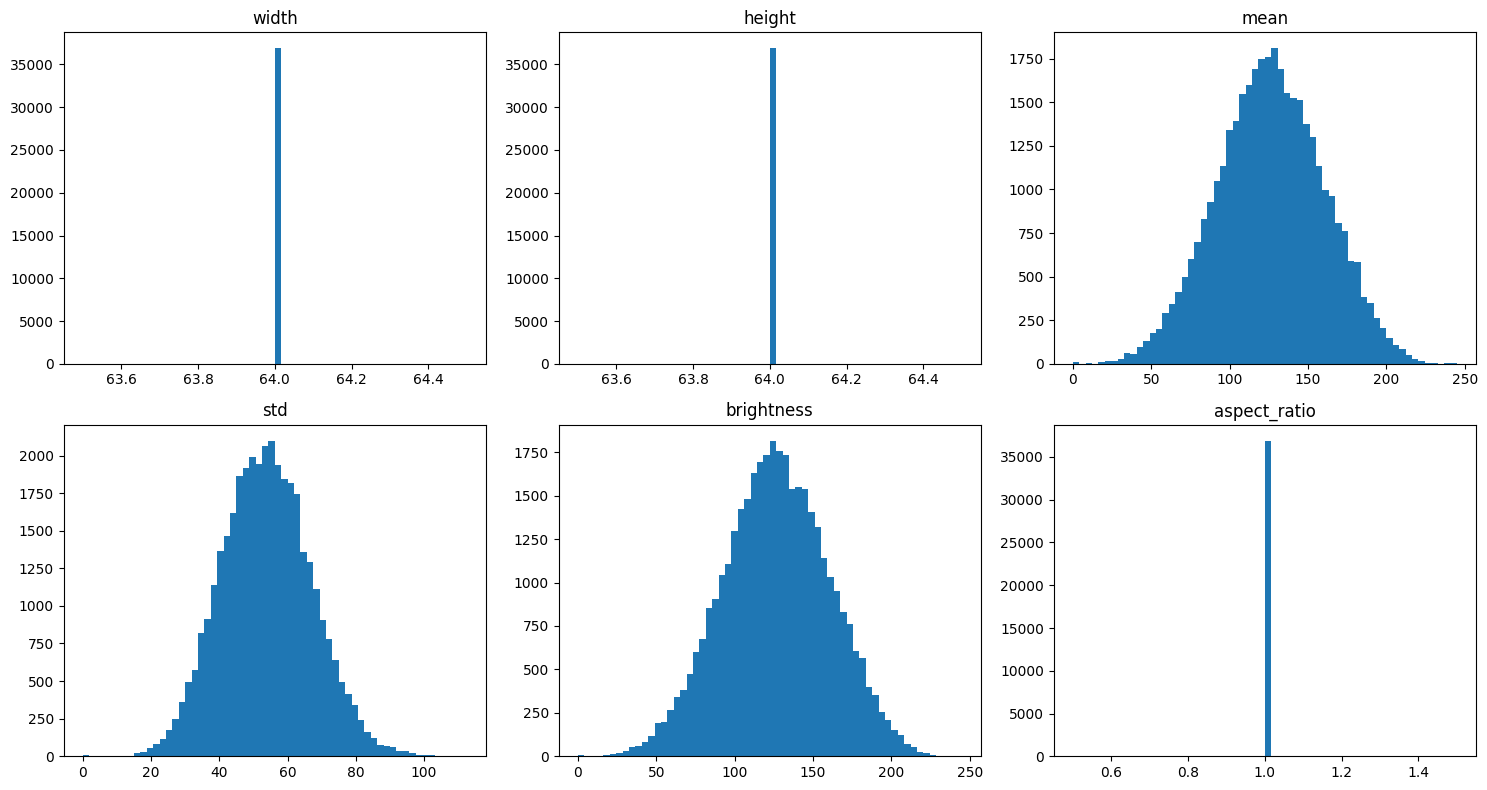

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.ravel()
cols = ['width','height','mean','std','brightness','aspect_ratio']
for ax, col in zip(axes, cols):
    ax.hist(df_stats[col], bins=60)
    ax.set_title(col)
plt.tight_layout()


In [ ]:
def iqr_flags(df, column, k=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k*IQR
    upper = Q3 + k*IQR
    return df[(df[column] < lower) | (df[column] > upper)].filepath.tolist()

stat_cols = ['width','height','mean','brightness','aspect_ratio']
iqr_outlier_files = set()
k = 1.5
for c in stat_cols:
    flagged = iqr_flags(df_stats, c, k=k)
    print(f"{c}: flagged {len(flagged)}")
    iqr_outlier_files.update(flagged)
print("Total stat-based outliers (IQR union):", len(iqr_outlier_files))


width: flagged 0
height: flagged 0
mean: flagged 123
brightness: flagged 137
aspect_ratio: flagged 0
Total stat-based outliers (IQR union): 139


In [ ]:
valid_paths = df_stats['filepath'].tolist()
n = len(valid_paths)
print("Images to embed:", n)

img_size = (224, 224)
base_model = MobileNetV2(include_top=False, weights='imagenet', pooling='avg',
                         input_shape=(img_size[0], img_size[1], 3))

def preprocess_for_mobilenet(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, img_size)
    image = preprocess_input(image * 255.0)
    return image

batch_size = 32
ds = tf.data.Dataset.from_tensor_slices(valid_paths)
ds = ds.map(lambda x: preprocess_for_mobilenet(x), num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

embeddings = base_model.predict(ds, verbose=1)
print("Embeddings shape:", embeddings.shape)

contamination = 0.02
iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42, n_jobs=-1)
iso.fit(embeddings)
pred = iso.predict(embeddings)
scores = iso.decision_function(embeddings)
outlier_idx = np.where(pred == -1)[0]
print("IsolationForest flagged:", len(outlier_idx), "images")

iso_outlier_files = [valid_paths[i] for i in outlier_idx]


Images to embed: 36912
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 1427s 1s/step
Embeddings shape: (36912, 1280)
IsolationForest flagged: 739 images


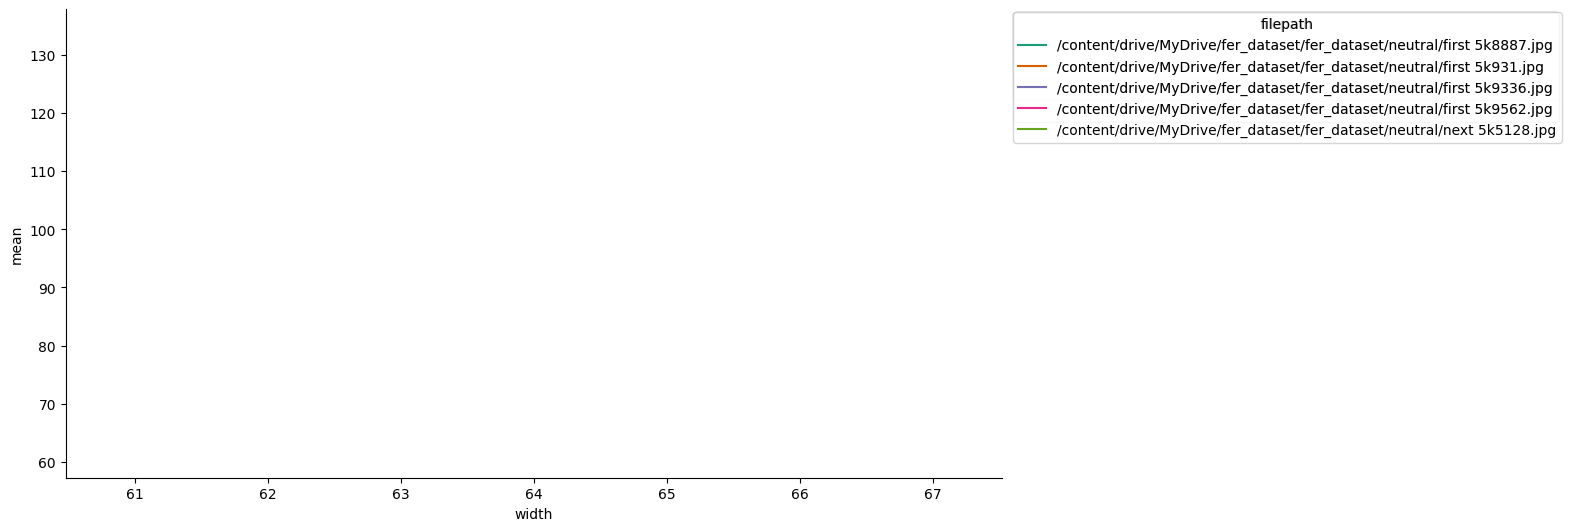

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['width']
  ys = series['mean']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_7.sort_values('width', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('filepath')):
  _plot_series(series, series_name, i)
  fig.legend(title='filepath', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('width')
_ = plt.ylabel('mean')

In [ ]:
combined_outliers = set(bad_files) | set(iqr_outlier_files) | set(iso_outlier_files)
print("Combined outlier count:", len(combined_outliers))

OUTLIERS_DIR = Path("/content/drive/MyDrive/fer_outliers")
OUTLIERS_DIR.mkdir(parents=True, exist_ok=True)

moved = 0
for p in combined_outliers:
    try:
        src = Path(p)
        cls = src.parent.name
        dest_dir = OUTLIERS_DIR / cls
        dest_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dest_dir / src.name)
        moved += 1
    except Exception as e:
        print("Failed to copy:", p, e)
print(f"Copied {moved} outliers to {OUTLIERS_DIR}")


Combined outlier count: 866
Copied 866 outliers to /content/drive/MyDrive/fer_outliers


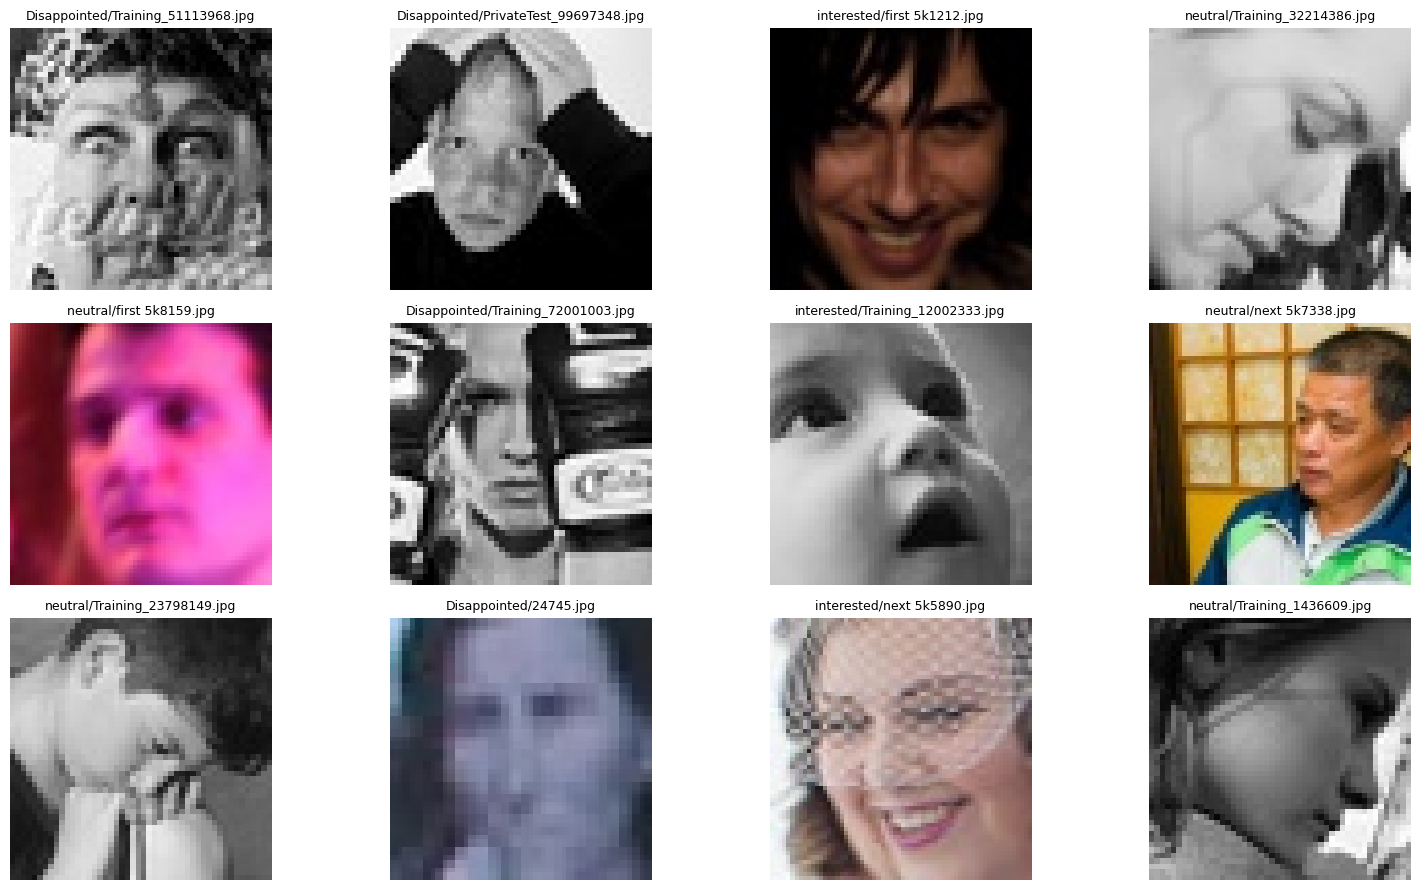

In [ ]:
from math import ceil
sample_out = list(combined_outliers)[:12]  # show up to 12
n = len(sample_out)
cols = 4
rows = ceil(n/cols)
plt.figure(figsize=(4*cols, 3*rows))
for i, p in enumerate(sample_out):
    ax = plt.subplot(rows, cols, i+1)
    try:
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.set_title(Path(p).parent.name + "/" + Path(p).name, fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, 'Cannot open', ha='center')
    ax.axis('off')
plt.tight_layout()


In [ ]:
CLEAN_DIR = Path("/content/drive/MyDrive/fer_dataset_cleaned")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

all_files = set(df_files['filepath'].tolist())
inliers = sorted(list(all_files - combined_outliers))
print("Inliers count:", len(inliers))

copied = 0
for p in tqdm(inliers):
    try:
        src = Path(p)
        cls = src.parent.name
        destdir = CLEAN_DIR / cls
        destdir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, destdir / src.name)
        copied += 1
    except Exception as e:
        print("copy failed:", p, e)

print(f"Copied {copied} files to cleaned dataset at {CLEAN_DIR}")


Inliers count: 36046


100%|██████████| 36046/36046 [08:10<00:00, 73.43it/s]

Copied 36046 files to cleaned dataset at /content/drive/MyDrive/fer_dataset_cleaned


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(CLEAN_DIR),
    image_size=img_size,
    batch_size=32,
    label_mode='categorical',
    shuffle=True
)
print(train_ds)


Found 36046 files belonging to 3 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>
